In [1]:
#Import Packages
from sympy import *
import numpy as np
import math
init_printing()
from scipy import integrate
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import matplotlib.colors as colors
from matplotlib.ticker import (MultipleLocator, AutoLocator, AutoMinorLocator, ScalarFormatter)
from matplotlib import gridspec
import latex

This code can calculate charge distribution for the following molecules:
Molecule 1: C60
To calculate charge distribution for Molecule 1, ENTER 1
Enter here.....1


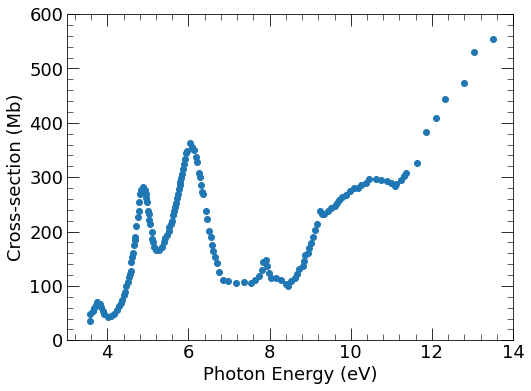

In [2]:
###############################################################################
# Constants

h = 6.6260755*10**(-27)  #Units: erg.s
c = 2.99793458*10**(10) #Units: cm/s
k = 1.380658*10**(-16) #Units: erg/K
eV = 1.60218*10**(-12) #Units: erg
L_sun = 3.8458*10**(33) #Units: erg/s
stefan_sigma = 5.67051*10**(-5) #Units: erg.cm^(-2).K^(-4).s^(-1)
###############################################################################

def planck_func(frequency_array, Temp):
    
    T = Temp
    B_nu_num = 2*h*(frequency_array**3)/(c**2)
    B_nu_denom = (np.exp(h*frequency_array/(k*T))) - 1
    B_nu = B_nu_num/B_nu_denom
    
    return B_nu

###############################################################################
###############################################################################
# Source
#These are the values we used to generate figure 2 and A1 in paper
gas_density = np.geomspace(100, 9381941, 50) #general paper and NGC 7023
#gas_density = np.geomspace(9299.230769230768, 62317738.873076916, 25) # NGC 2023
#gas_density = np.geomspace(14000, 93819410, 25)

#gas_density = np.array([8*10**(4)])

# Radiation field strength #
G_0 = np.full((len(gas_density)), 2600)

gas_temp = np.full((len(gas_density)), 400)

e_abund = np.full((len(gas_density)), 1.6*10**(-4))

temp_star = 17000 # K

###############################################################################
# Molecule
print ('=====================================================================')
print ('This code can calculate charge distribution for the following molecules:')
print ('Molecule 1: C60')
print ('=====================================================================')
print ('To calculate charge distribution for Molecule 1, ENTER 1')
print ('=====================================================================')
n_PAH = input('Enter here.....')
n_PAH = int(n_PAH) 

# Symbols for characteristics of PAHs #
NC_PAH, Z = symbols('NC_PAH, Z')
expr_NC = 1*NC_PAH

# Number of C atoms in PAH molecule #
if n_PAH == 1:
    NC = expr_NC.subs(NC_PAH, 60)
else:
    pass
# Ionization Potential of PAHs #
# Units of I.P. are eV #
if n_PAH == 1:
    IP_0 = 7.6 # Malloci Database
    IP_1 = 11.5 # Malloci Database
    IP_neg1 = 2.65 # Malloci Database
else:
    pass

# Absorption cross-section of PAHs #
# Units of absorption cross-section are Mb #
# All values are taken from Malloci Database #
if n_PAH == 1:
    data = np.loadtxt("cross_section_fullerenes_final.csv",
                delimiter = ',')
    data = data.T
    ab_0 = data[:,1]
    ab_0_energy = data[:,0]
    
    ab_1 = ab_0
    ab_1_energy = ab_0_energy
    
    ab_2 = ab_0
    ab_2_energy = ab_0_energy
    
    ab_neg1 = ab_0
    ab_neg1_energy = ab_0_energy
    
else:
    pass

fig = plt.figure(figsize=(8, 6))
ax = plt.axes()
plt.plot(ab_0_energy, ab_0, marker = 'o', linestyle = '')
plt.xlim(3, 14)
plt.ylim(0, 600)
ax.set_xlabel(r'Photon Energy (eV)',fontsize=18)
ax.set_ylabel('Cross-section (Mb)',fontsize=18)
ax.tick_params(direction='in', which = 'major', bottom= True, left= True, top=True, right=True, length = 12, labelsize =18)
ax.tick_params(direction='in', which = 'minor', bottom= True, left= True, top=True, right=True, length = 6)
majorLocator = AutoLocator()
ax.xaxis.set_major_locator(majorLocator)
minorLocator = MultipleLocator(0.4)
ax.xaxis.set_minor_locator(minorLocator)
majorLocator = AutoLocator()
ax.yaxis.set_major_locator(majorLocator)
minorLocator = MultipleLocator(20)
ax.yaxis.set_minor_locator(minorLocator)
plt.savefig('cross-section_C60.eps',  bbox_inches='tight')
plt.show()
###############################################################################
def photo_ionization_rate(abs_xsection, abs_xsection_energy, IP, G_0):
    
    
    ind = np.where((abs_xsection_energy>0) & (abs_xsection_energy<13.6))
    energy = abs_xsection_energy[ind] # Units:eV
    abs_cross_section = abs_xsection[ind] # Units: Mb
    abs_cross_section = abs_cross_section*(10**(-18)) # Units: cm^2
    ind_0 = np.where(energy>IP)
    abs_cross_section = abs_cross_section[ind_0]
    energy = energy[ind_0]
    frequency_array = energy*eV/h
    
    B_nu_array = planck_func(frequency_array, temp_star)
    mean_photon_intensity = B_nu_array/(h*frequency_array)
    
    ioniza_yield = np.array([])
    for i in range (0, len(energy)):
        if energy[i] >= (IP+9.2):
            y = 1
        else:
            y = (energy[i]-IP)/9.2
        ioniza_yield = np.append(ioniza_yield, y)
    
    J_PE = np.array([])
    for i in range (0, len(G_0)):
        
        energy_array_FUV = np.linspace(6, 13.6, 1000)
        frequency_array_FUV = energy_array_FUV*eV/h
        B_nu_FUV = planck_func(frequency_array_FUV, temp_star)
        Total_flux = stefan_sigma*(temp_star)**(4)
        Flux_FUV = (math.pi)*(integrate.simps(B_nu_FUV, frequency_array_FUV))
        frac_FUV = Flux_FUV/Total_flux
        Field_dilution_factor = 1.6*10**(-3)*(G_0[i])/(stefan_sigma*((temp_star)**(4))*frac_FUV)
        
        expr = (math.pi)*Field_dilution_factor*ioniza_yield*abs_cross_section*mean_photon_intensity
        J_PE_val = (integrate.simps(expr, frequency_array)) 
        J_PE = np.append(J_PE, J_PE_val)
        
    
    photo_ioniz_rate = J_PE    
    
    
    return photo_ioniz_rate

###############################################################################
def electron_recombination_rate(electron_abundance,
                                gas_density,
                                Temp,
                                NC, 
                                charge_state):
    

    expr_J_e = 1.8*10**(-6)*7.1*electron_abundance*gas_density*((300/Temp)**0.5)*charge_state  # Xander's Book
    elec_recom_rate = expr_J_e
    
    return elec_recom_rate

###############################################################################
def electron_attachment_rate(electron_abundance,
                             gas_density):
    
    expr_J_ea = 10**(-6)*gas_density*electron_abundance # Xander's Book 
    elec_attach_rate = expr_J_ea
        
    return elec_attach_rate

In [3]:

############### Now lets solve
f_0, f_1, f_2, f_3, f_4, f_neg1 = symbols('f_0, f_1, f_2, f_3, f_4, f_neg1')
result_f_0 = np.array([])
result_f_1 = np.array([])
result_f_2 = np.array([])
result_f_3 = np.array([])
result_f_4 = np.array([])
result_f_neg1 = np.array([])
if n_PAH == 1:
    J_PE_0 = photo_ionization_rate(ab_0, ab_0_energy, IP_0, G_0)
    J_PE_1 = photo_ionization_rate(ab_1, ab_1_energy, IP_1, G_0)
    J_PE_neg1 = photo_ionization_rate(ab_neg1, ab_neg1_energy, IP_neg1, G_0)
    J_e_1 = electron_recombination_rate(e_abund, gas_density, gas_temp, NC, 1)
    J_e_2 = electron_recombination_rate(e_abund, gas_density, gas_temp, NC, 2)
    J_ea_0 = electron_attachment_rate(e_abund, gas_density)
    for i in range (0, len(G_0)):
        eq1 = Eq(f_0 + f_1 + f_2 + f_neg1 - 1,0)
        eq2 = Eq(f_1 - (f_0*(J_PE_0[i]/J_e_1[i])),0)
        eq3 = Eq(f_2 - (f_1*(J_PE_1[i]/J_e_2[i])),0)
        eq4 = Eq(f_neg1 - f_0*(J_ea_0[i]/J_PE_neg1[i]),0)
        a = solve([eq1,eq2,eq3,eq4], (f_0,f_1,f_2,f_neg1))
        result_f_0 = np.append(result_f_0, a[f_0])
        result_f_1 = np.append(result_f_1, a[f_1])
        result_f_2 = np.append(result_f_2, a[f_2])
        result_f_neg1 = np.append(result_f_neg1, a[f_neg1])
else:
    pass



[19029.41402321 15064.33808924 11925.44771951  9440.59423444]
[0.754559898995896 0.781825010237278 0.800988574270869 0.811900955120385]
[0.207924338722107 0.170547676093537 0.138320709127720 0.110991207645125]
[0.00223697716853461 0.00145253520600036 0.000932594193265979
 0.000592405000656203]
[0.0352787851134623 0.0461747784631844 0.0597581224081452
 0.0765154322338336]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


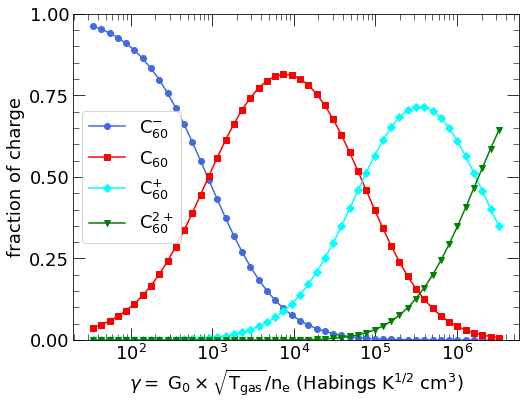

In [4]:
gamma = G_0*(gas_temp)**(0.5)/(gas_density*e_abund)
ind = np.where((gamma>9*10**(3))&(gamma<2*10**(4)))
print (gamma[ind])
print (result_f_0[ind])
print (result_f_1[ind])
print (result_f_2[ind])
print (result_f_neg1[ind])
fig = plt.figure(figsize=(8, 6))
ax = plt.axes()
plt.plot(gamma, result_f_neg1, color='royalblue', marker = 'o', markersize=6, linestyle='solid',
         label= r'C$_{60}^{-}$')
plt.plot(gamma, result_f_0, color='red', marker = 's', markersize=6, linestyle='solid',
         label = r'C$_{60}$')
plt.plot(gamma, result_f_1, color='cyan', marker = 'D', markersize=6, linestyle='solid',
         label = r'C$_{60}^{+}$')
plt.plot(gamma, result_f_2, color='green', marker = 'v', markersize=6, linestyle='solid',
         label = r'C$_{60}^{2+}$')
ax.set_xlabel(r'$\gamma =$ G$_{0} \times \sqrt{\rm T_{\rm gas}} /\rm n_{\rm e}$ (Habings K$^{1/2}$ cm$^{3}$)',fontsize=18)
ax.set_ylabel('fraction of charge',fontsize=18)
ax.tick_params(direction='in', which = 'major', bottom= True, left= True, top=True, right=True, length = 12, labelsize =18)
ax.tick_params(direction='in', which = 'minor', bottom= True, left= True, top=True, right=True, length = 6)
plt.ylim(0, 1)
#plt.xlim(0, 5.5)
ax.set_xscale('log')
majorLocator = MultipleLocator(0.25) 
ax.yaxis.set_major_locator(majorLocator)
minorLocator = MultipleLocator(0.05)
ax.yaxis.set_minor_locator(minorLocator)
plt.legend(fontsize = 18)
plt.savefig('charge_distribution_fullerenes_7023.eps', bbox_inches='tight')
plt.show()



In [ ]:
if n_PAH == 1:
    np.savetxt("fullerene_charge_G0_2600.csv",
           (result_f_neg1, result_f_0, result_f_1, result_f_2), 
           delimiter=",", header = "anion, neutral, cation, dication")

In [ ]:
print (gamma)